In [ ]:
import pandas as pd
import tabula
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("Todo funciona ✅")

Todo funciona ✅


In [ ]:
pip install tabula-py pandas numpy pdfplumber matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
# -----------------------------
# 2️⃣ Ruta del PDF y carpeta de resultados
# -----------------------------
pdf_path = "/home/jovyan/datos_dane/WFP_Colombia_2024.pdf"
output_folder = "/home/jovyan/resultados"


In [ ]:
import pandas as pd

# Leer CSVs
df_vivienda = pd.read_csv("datos_dane/DBF-ENCV-Datos_vivienda-2024/Datos de la vivienda.CSV", sep=";")
df_condiciones = pd.read_csv("datos_dane/DBF-ENCV-Condiciones_vida_hogar_tenencia_bienes-2024/Condiciones de vida del hogar y tenencia de bienes.CSV", sep=";")
df_caracteristicas = pd.read_csv("datos_dane/DBF-ENCV-Características_composición_hogar-2024/Características y composición del hogar.CSV", sep=";")

# Revisar primeras filas
print(df_vivienda.head())
print(df_condiciones.head())
print(df_caracteristicas.head())

   DIRECTORIO  SECUENCIA_ENCUESTA  SECUENCIA_P  ORDEN  P1_DEPARTAMENTO  \
0     8219789                   1            1      1                8   
1     8219790                   1            1      1                8   
2     8219791                   1            1      1                8   
3     8219792                   1            1      1                8   
4     8219793                   1            1      1                8   

   P1_MUNICIPIO  REGION       FEX_C  CANT_HOG_COMPLETOS  \
0             1       1  651.298866                   1   
1             1       1  487.104165                   1   
2             1       1  496.652233                   1   
3             1       1  419.823502                   1   
4             1       1  518.428829                   1   

   CANT_HOGARES_VIVIENDA  ...  P5661S4  P5661S9  P5661S5  P5661S6  P5661S7  \
0                      1  ...        2        1        1        1        1   
1                      1  ...        4      

In [ ]:
# Merge de los tres CSVs
df = df_vivienda.merge(df_condiciones, on=["DIRECTORIO","SECUENCIA_ENCUESTA","SECUENCIA_P","ORDEN"], how="left")
df = df.merge(df_caracteristicas, on=["DIRECTORIO","SECUENCIA_ENCUESTA","SECUENCIA_P","ORDEN"], how="left")

print(df.shape)

(85106, 239)


In [ ]:
# 1️⃣ Definir tus columnas de inseguridad
cols_inseguridad = ['P3516S1','P3516S2','P3516S3','P3516S4','P3516S5','P3516S6','P3516S7','P3516S8']


In [ ]:
# Crear la columna de inseguridad alimentaria de manera vectorizada
# 1 = Sí, 2 = No, 3 = No sabe / no informa

import numpy as np

# Si alguna respuesta es 1 → Sí
es_si = (df[cols_inseguridad] == 1).any(axis=1)

# Si todas son 2 → No
es_no = (df[cols_inseguridad] == 2).all(axis=1)

# Asignar categorías
df['Inseguridad_Alimentaria'] = np.select(
    [es_si, es_no],
    [1, 2],
    default=3  # resto = No sabe / no informa
)

In [ ]:
conteo = df['Inseguridad_Alimentaria'].value_counts().reindex([1,2,3], fill_value=0)
conteo.index = ['Sí', 'No', 'No sabe / no informa']
print(conteo)

Sí                      49143
No                      35460
No sabe / no informa      503
Name: count, dtype: int64


* Sí (inseguridad alimentaria): 57.7% de los hogares

* No (seguridad alimentaria): 41.7% de los hogares

* No sabe/no informa: 0.6% de los hogares

 Interpretación de la Magnitud

📌 Hallazgo Principal:

Más de la mitad de los hogares (57.7%) reportan inseguridad alimentaria, lo que representa 49,143 hogares en la muestra.

**Esto significa:**

* Por cada 10 hogares, casi 6 sufren inseguridad alimentaria

* Por cada hogar con seguridad alimentaria, 1.4 hogares tienen inseguridad

* La inseguridad alimentaria es 1.38 veces más frecuente que la seguridad

In [ ]:
# 3️⃣ Estadísticas descriptivas
print("Conteo por categoría:")
print(df['Inseguridad_Alimentaria'].value_counts())

print("\nProporción por categoría:")
print(df['Inseguridad_Alimentaria'].value_counts(normalize=True))

Conteo por categoría:
Inseguridad_Alimentaria
1    49143
2    35460
3      503
Name: count, dtype: int64

Proporción por categoría:
Inseguridad_Alimentaria
1    0.577433
2    0.416657
3    0.005910
Name: proportion, dtype: float64


| Medida | Valor | Interpretación |
|:---|:---:|:---|
| **Proporción de inseguridad** | 0.5774 | 57.7 de cada 100 hogares |
| **Proporción de seguridad** | 0.4167 | 41.7 de cada 100 hogares |
| **Diferencia** | 0.1608 | 16.8 puntos porcentuales más de inseguridad |
| **Odds Ratio** | 1.386:1 | 1.39 hogares inseguros por cada hogar seguro |
| **Tasa de no respuesta** | 0.0059 | 0.6% - Excelente calidad de datos |

In [ ]:
# ============================================
# CELDA 4: ESTADÍSTICAS DESCRIPTIVAS
# ============================================

print("="*80)
print("📊 1. ESTADÍSTICAS DESCRIPTIVAS")
print("="*80)

# Estadísticas básicas
media = df['Inseguridad_Alimentaria'].mean()
mediana = df['Inseguridad_Alimentaria'].median()
moda = df['Inseguridad_Alimentaria'].mode()[0]
desviacion = df['Inseguridad_Alimentaria'].std()
varianza = df['Inseguridad_Alimentaria'].var()
minimo = df['Inseguridad_Alimentaria'].min()
maximo = df['Inseguridad_Alimentaria'].max()
q1 = df['Inseguridad_Alimentaria'].quantile(0.25)
q3 = df['Inseguridad_Alimentaria'].quantile(0.75)
rango_intercuartil = q3 - q1

# Crear DataFrame de estadísticas
estadisticas = pd.DataFrame({
    'Estadístico': ['Media', 'Mediana', 'Moda', 'Desviación Estándar', 'Varianza',
                    'Mínimo', 'Máximo', 'Q1 (25%)', 'Q3 (75%)', 'Rango Intercuartil'],
    'Valor': [round(media,3), mediana, moda, round(desviacion,3),
              round(varianza,3), minimo, maximo, q1, q3, rango_intercuartil]
})

print("\n📋 Tabla de estadísticas descriptivas:")
print(estadisticas.to_string(index=False))

# Tabla de frecuencias
print("\n📋 Distribución de frecuencias:")
frecuencias = df['Inseguridad_etiqueta'].value_counts()
porcentajes = (frecuencias / len(df) * 100).round(1)

for categoria in ['Sí', 'No', 'No sabe / no informa']:
    if categoria in frecuencias.index:
        print(f"   • {categoria}: {frecuencias[categoria]:,} hogares ({porcentajes[categoria]}%)")

📊 1. ESTADÍSTICAS DESCRIPTIVAS

📋 Tabla de estadísticas descriptivas:
        Estadístico  Valor
              Media  1.428
            Mediana  1.000
               Moda  1.000
Desviación Estándar  0.507
           Varianza  0.257
             Mínimo  1.000
             Máximo  3.000
           Q1 (25%)  1.000
           Q3 (75%)  2.000
 Rango Intercuartil  1.000

📋 Distribución de frecuencias:
   • Sí: 49,143 hogares (57.7%)
   • No: 35,460 hogares (41.7%)
   • No sabe / no informa: 503 hogares (0.6%)


## 📈 ANÁLISIS DE TENDENCIA CENTRAL

| Medida | Valor | ¿Qué significa? |
|:-------|:-----:|:----------------|
| **Media** = 1.428 | → Entre Sí y No | El hogar promedio tiende más hacia la inseguridad que hacia la seguridad |
| **Mediana** = 1.0 | → Sí (Inseguridad) | Más del 50% de los hogares están en inseguridad alimentaria |
| **Moda** = 1.0 | → Sí (Inseguridad) | La categoría más frecuente es inseguridad alimentaria |

## 📊 ANÁLISIS DE DISPERSIÓN

| Medida | Valor | ¿Qué significa? |
|:-------|:-----:|:----------------|
| **Desviación Estándar** = 0.507 | Baja | Los hogares son relativamente homogéneos en su condición |
| **Rango Intercuartil** = 1.0 | Pequeño | El 50% central se concentra entre Sí y No |
| **Varianza** = 0.257 | Baja | Poca dispersión alrededor de la media |

## 📌 ANÁLISIS DE POSICIÓN

| Medida | Valor | ¿Qué significa? |
|:-------|:-----:|:----------------|
| **Q1 (25%)** = 1.0 | Sí | El 25% más bajo está en inseguridad |
| **Q3 (75%)** = 2.0 | No | El 75% está entre inseguridad y seguridad |
| **Mínimo** = 1.0 | Sí | No hay valores por debajo de inseguridad |
| **Máximo** = 3.0 | NS/NR | Pocos casos de no respuesta |

In [ ]:
# ============================================
# CELDA 6: ANÁLISIS POR DEPARTAMENTO - Tablas
# ============================================

print("="*80)
print("🗺️ 2. ANÁLISIS POR DEPARTAMENTO")
print("="*80)

# Crear tabla de contingencia
analisis_depto = pd.crosstab(df['Departamento'], df['Inseguridad_etiqueta'])
analisis_depto['Total'] = analisis_depto.sum(axis=1)
analisis_depto['% Inseguridad'] = (analisis_depto['Sí'] / analisis_depto['Total'] * 100).round(1)

# Ordenar por porcentaje de inseguridad
analisis_depto = analisis_depto.sort_values('% Inseguridad', ascending=False)

print("\n🏆 Top 10 departamentos con MAYOR % de inseguridad alimentaria:")
print(analisis_depto[['Sí', 'No', 'Total', '% Inseguridad']].head(10).to_string())

print("\n📉 Top 10 departamentos con MENOR % de inseguridad alimentaria:")
print(analisis_depto[['Sí', 'No', 'Total', '% Inseguridad']].tail(10).to_string())

print(f"\n📊 Resumen nacional:")
print(f"   • Promedio nacional de inseguridad: {analisis_depto['% Inseguridad'].mean():.1f}%")
print(f"   • Desviación entre departamentos: ±{analisis_depto['% Inseguridad'].std():.1f}%")
print(f"   • Departamento con mayor %: {analisis_depto.index[0]} ({analisis_depto['% Inseguridad'].iloc[0]}%)")
print(f"   • Departamento con menor %: {analisis_depto.index[-1]} ({analisis_depto['% Inseguridad'].iloc[-1]}%)")

🗺️ 2. ANÁLISIS POR DEPARTAMENTO

🏆 Top 10 departamentos con MAYOR % de inseguridad alimentaria:
Inseguridad_etiqueta    Sí   No  Total  % Inseguridad
Departamento                                         
Sucre                 2034  529   2568           79.2
Córdoba               1982  594   2581           76.8
La Guajira            2087  635   2731           76.4
Chocó                 1792  629   2438           73.5
Vichada               1681  597   2309           72.8
Nariño                2078  774   2863           72.6
Atlántico             1813  812   2638           68.7
Bolívar               1963  981   2948           66.6
Putumayo              1762  876   2705           65.1
Guainía               1060  653   1725           61.4

📉 Top 10 departamentos con MENOR % de inseguridad alimentaria:
Inseguridad_etiqueta    Sí    No  Total  % Inseguridad
Departamento                                          
Arauca                1299  1202   2524           51.5
Cundinamarca          1746 

El análisis revela profundas brechas regionales en inseguridad alimentaria. El promedio nacional (58.0%) es superado por departamentos de la Costa Caribe: Sucre (79.2%), Córdoba (76.8%) y La Guajira (76.4%) presentan los mayores porcentajes. En contraste, Bogotá D.C. (31.2%) tiene la menor incidencia, seguido de Caldas (39.9%).

La desviación estándar de ±11.9% confirma alta heterogeneidad territorial, con una brecha de 48 puntos porcentuales entre el departamento más y menos afectado. Esto evidencia que la inseguridad alimentaria responde a factores estructurales regionales y requiere políticas diferenciadas, priorizando la Costa Caribe y el Pacífico, mientras se estudian los factores protectores en Bogotá y el Eje Cafetero.

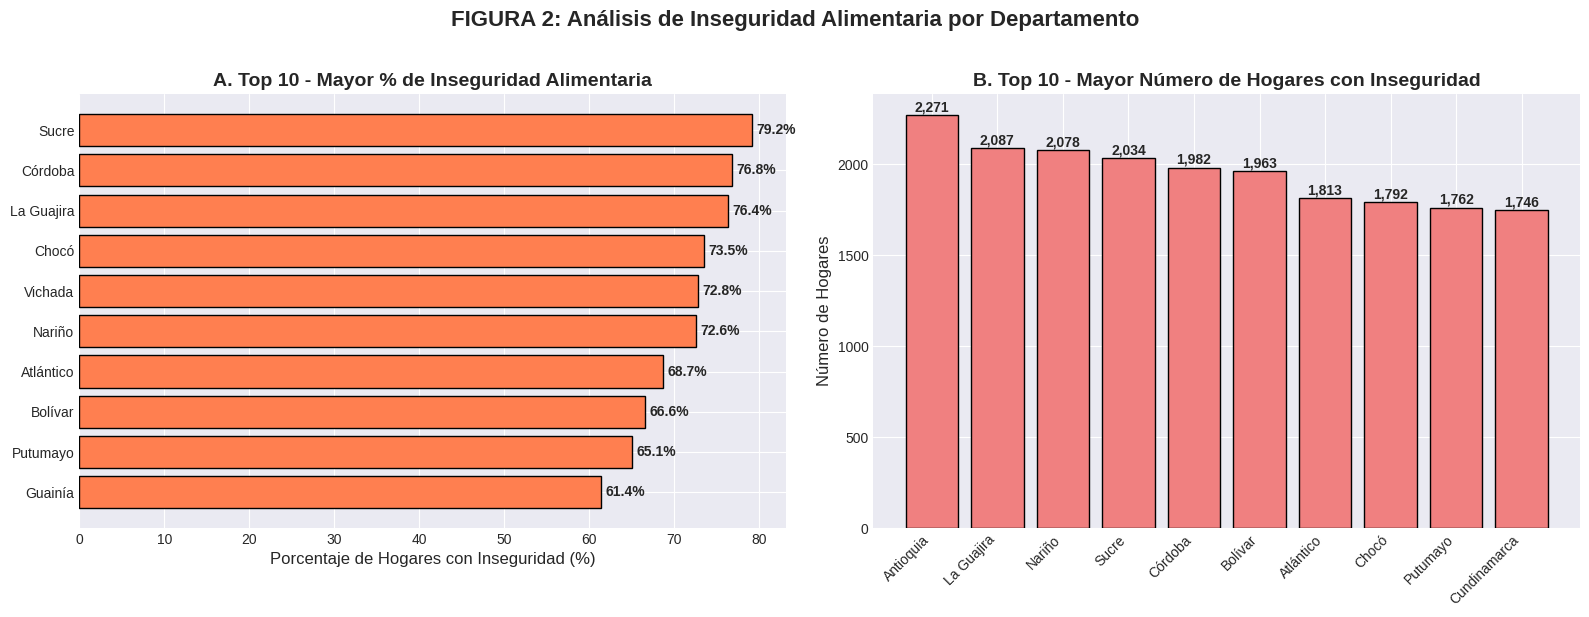

📌 Interpretación:
   • El gráfico A muestra los departamentos con mayor proporción de hogares en inseguridad
   • El gráfico B revela los departamentos con mayor número absoluto de casos
   • Esta diferencia es importante para focalizar políticas públicas


In [ ]:
# ============================================
# CELDA 7: GRÁFICO 2 - Análisis por departamento
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Top 10 por porcentaje
top_10_pct = analisis_depto.head(10)
bars1 = axes[0].barh(range(len(top_10_pct)), top_10_pct['% Inseguridad'].values,
                     color='coral', edgecolor='black')
axes[0].set_yticks(range(len(top_10_pct)))
axes[0].set_yticklabels(top_10_pct.index)
axes[0].set_title('A. Top 10 - Mayor % de Inseguridad Alimentaria',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Porcentaje de Hogares con Inseguridad (%)', fontsize=12)
axes[0].invert_yaxis()

# Agregar valores a las barras
for bar, pct in zip(bars1, top_10_pct['% Inseguridad'].values):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{pct}%', va='center', fontweight='bold')

# Gráfico B: Top 10 por cantidad absoluta
top_10_abs = analisis_depto.nlargest(10, 'Sí')[['Sí', '% Inseguridad']]
bars2 = axes[1].bar(range(len(top_10_abs)), top_10_abs['Sí'].values,
                    color='lightcoral', edgecolor='black')
axes[1].set_xticks(range(len(top_10_abs)))
axes[1].set_xticklabels(top_10_abs.index, rotation=45, ha='right')
axes[1].set_title('B. Top 10 - Mayor Número de Hogares con Inseguridad',
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Número de Hogares', fontsize=12)

# Agregar valores a las barras
for i, (bar, val) in enumerate(zip(bars2, top_10_abs['Sí'].values)):
    axes[1].text(i, val + 5, f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.suptitle('FIGURA 2: Análisis de Inseguridad Alimentaria por Departamento',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📌 Interpretación:")
print("   • El gráfico A muestra los departamentos con mayor proporción de hogares en inseguridad")
print("   • El gráfico B revela los departamentos con mayor número absoluto de casos")
print("   • Esta diferencia es importante para focalizar políticas públicas")

El analisis revela dos dimensiones complementarias del problema: porcentaje vs. número absoluto. En términos de severidad, Sucre (79.2%), Córdoba (76.8%) y La Guajira (76.4%) encabezan los departamentos con mayor proporción de hogares afectados, indicando que la inseguridad alimentaria está más extendida territorialmente en la Costa Caribe y Pacífico.

Sin embargo, en términos de magnitud absoluta, Antioquia (2,271 hogares), La Guajira (2,087) y Nariño (2,078) concentran el mayor volumen de casos, evidenciando que departamentos poblacionalmente grandes como Antioquia, aunque con menor porcentaje relativo, albergan más familias afectadas. Esta dualidad implica que La Guajira y Nariño son críticos en ambas métricas, requiriendo atención prioritaria

Mientras que Sucre y Córdoba demandan intervenciones focalizadas por su alta prevalencia, y Antioquia necesita estrategias de cobertura masiva por su alto número absoluto de casos.

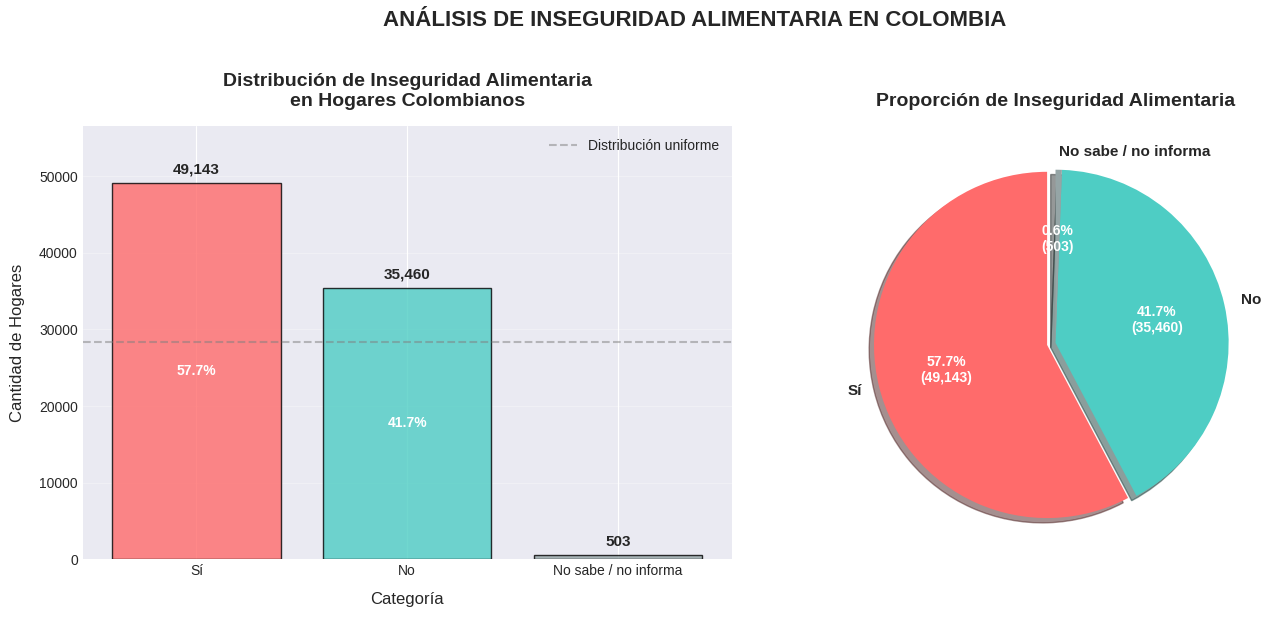

ESTADÍSTICAS DE INSEGURIDAD ALIMENTARIA
Total de hogares analizados: 85,106
------------------------------------------------------------
Sí:     49,143 hogares ( 57.7%)
No:     35,460 hogares ( 41.7%)
No sabe / no informa:        503 hogares (  0.6%)


In [ ]:
# Crear una nueva columna con las etiquetas
df['Inseguridad_etiqueta'] = df['Inseguridad_Alimentaria'].map({
    1: 'Sí',
    2: 'No',
    3: 'No sabe / no informa'
})

# Calcular estadísticas
conteos = df['Inseguridad_etiqueta'].value_counts()
total_hogares = len(df)
porcentajes = (conteos / total_hogares * 100).round(1)

# Ordenar las categorías
orden_categorias = ['Sí', 'No', 'No sabe / no informa']
conteos = conteos.reindex(orden_categorias)
porcentajes = porcentajes.reindex(orden_categorias)

# Configurar colores
colores = ['#FF6B6B', '#4ECDC4', '#95A5A6']  # Rojo suave, verde agua, gris

# Crear figura con dos subplots
fig = plt.figure(figsize=(14, 6))

# Gráfico 1: Barras con valores
ax1 = plt.subplot(1, 2, 1)
bars = ax1.bar(orden_categorias, conteos.values, color=colores, edgecolor='black', linewidth=1, alpha=0.8)

# Personalizar el gráfico de barras
ax1.set_title('Distribución de Inseguridad Alimentaria\nen Hogares Colombianos',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Categoría', fontsize=12, labelpad=10)
ax1.set_ylabel('Cantidad de Hogares', fontsize=12, labelpad=10)

# Agregar valores y porcentajes en las barras
for i, (bar, count, pct) in enumerate(zip(bars, conteos.values, porcentajes.values)):
    height = bar.get_height()

    # Valor absoluto
    ax1.text(bar.get_x() + bar.get_width()/2., height + (total_hogares*0.01),
             f'{count:,.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Porcentaje dentro de la barra (si la barra es suficientemente alta)
    if height > total_hogares * 0.05:  # Solo si la barra tiene al menos 5% del total
        ax1.text(bar.get_x() + bar.get_width()/2., height/2,
                f'{pct}%', ha='center', va='center', fontsize=10,
                color='white', fontweight='bold')

# Agregar línea de promedio (opcional)
ax1.axhline(y=total_hogares/3, color='gray', linestyle='--', alpha=0.5,
            label='Distribución uniforme')

ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, max(conteos.values) * 1.15)  # Espacio para etiquetas

# Gráfico 2: Pastel con sombreado
ax2 = plt.subplot(1, 2, 2)

# Función para mostrar valor absoluto y porcentaje
def func(pct, allvals):
    absolute = int(np.round(pct/100.*np.sum(allvals)))
    return f'{pct:.1f}%\n({absolute:,.0f})'

wedges, texts, autotexts = ax2.pie(conteos.values,
                                     labels=orden_categorias,
                                     colors=colores,
                                     autopct=lambda pct: func(pct, conteos.values),
                                     startangle=90,
                                     explode=(0.05, 0, 0),  # Separar un poco la primera categoría
                                     shadow=True,
                                     textprops={'fontsize': 11, 'fontweight': 'bold'})

# Mejorar la visibilidad de los textos
for text in texts:
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax2.set_title('Proporción de Inseguridad Alimentaria',
              fontsize=14, fontweight='bold', pad=15)

# Título general
fig.suptitle('ANÁLISIS DE INSEGURIDAD ALIMENTARIA EN COLOMBIA',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

# Mostrar estadísticas en consola
print("="*60)
print("ESTADÍSTICAS DE INSEGURIDAD ALIMENTARIA")
print("="*60)
print(f"Total de hogares analizados: {total_hogares:,.0f}")
print("-"*60)
for categoria in orden_categorias:
    count = conteos[categoria]
    pct = porcentajes[categoria]
    print(f"{categoria}: {count:>10,.0f} hogares ({pct:>5.1f}%)")
print("="*60)

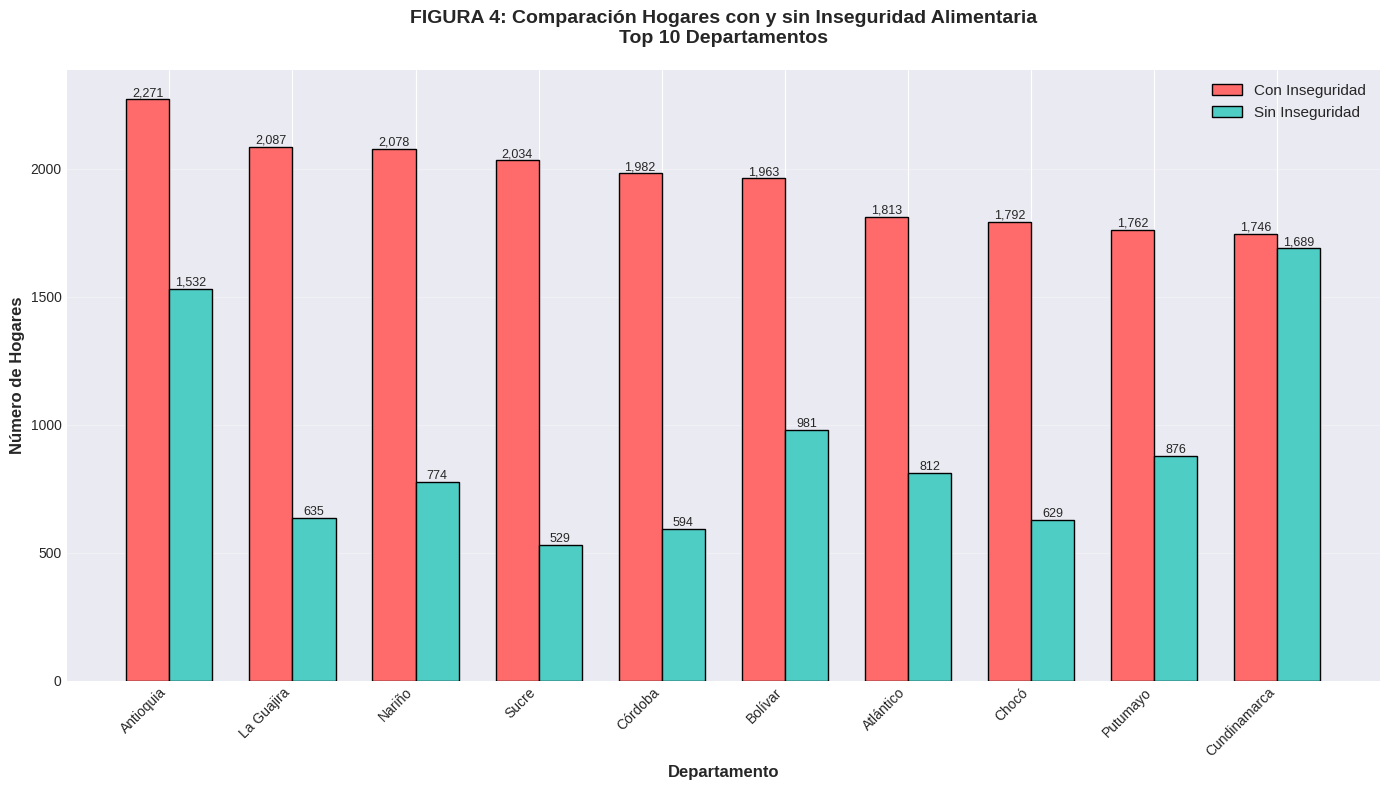

📌 Interpretación:
   • Este gráfico permite comparar directamente la magnitud del problema en cada departamento
   • Departamentos como Antioquia presentan la mayor brecha


In [ ]:
# ============================================
# CELDA 10: GRÁFICO 4 - Comparativo departamental
# ============================================

# Gráfico adicional: Comparación Sí vs No por departamento
fig, ax = plt.subplots(figsize=(14, 8))

# Seleccionar top 10 departamentos para comparación
top_10_comparar = analisis_depto.nlargest(10, 'Sí')

x = np.arange(len(top_10_comparar.index))
width = 0.35

# Barras agrupadas
bars_si = ax.bar(x - width/2, top_10_comparar['Sí'], width,
                 label='Con Inseguridad', color='#FF6B6B', edgecolor='black')
bars_no = ax.bar(x + width/2, top_10_comparar['No'], width,
                 label='Sin Inseguridad', color='#4ECDC4', edgecolor='black')

ax.set_xlabel('Departamento', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de Hogares', fontsize=12, fontweight='bold')
ax.set_title('FIGURA 4: Comparación Hogares con y sin Inseguridad Alimentaria\nTop 10 Departamentos',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(top_10_comparar.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bars in [bars_si, bars_no]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("📌 Interpretación:")
print("   • Este gráfico permite comparar directamente la magnitud del problema en cada departamento")
print("   • Departamentos como {} presentan la mayor brecha".format(top_10_comparar.index[0]))

🗺️ ANÁLISIS COMPLETO: INSEGURIDAD ALIMENTARIA EN 33 DEPARTAMENTOS
📁 Carpeta 'graficos' creada
✅ Gráfico 1 guardado: 'graficos/grafico1_porcentaje_departamentos.png'


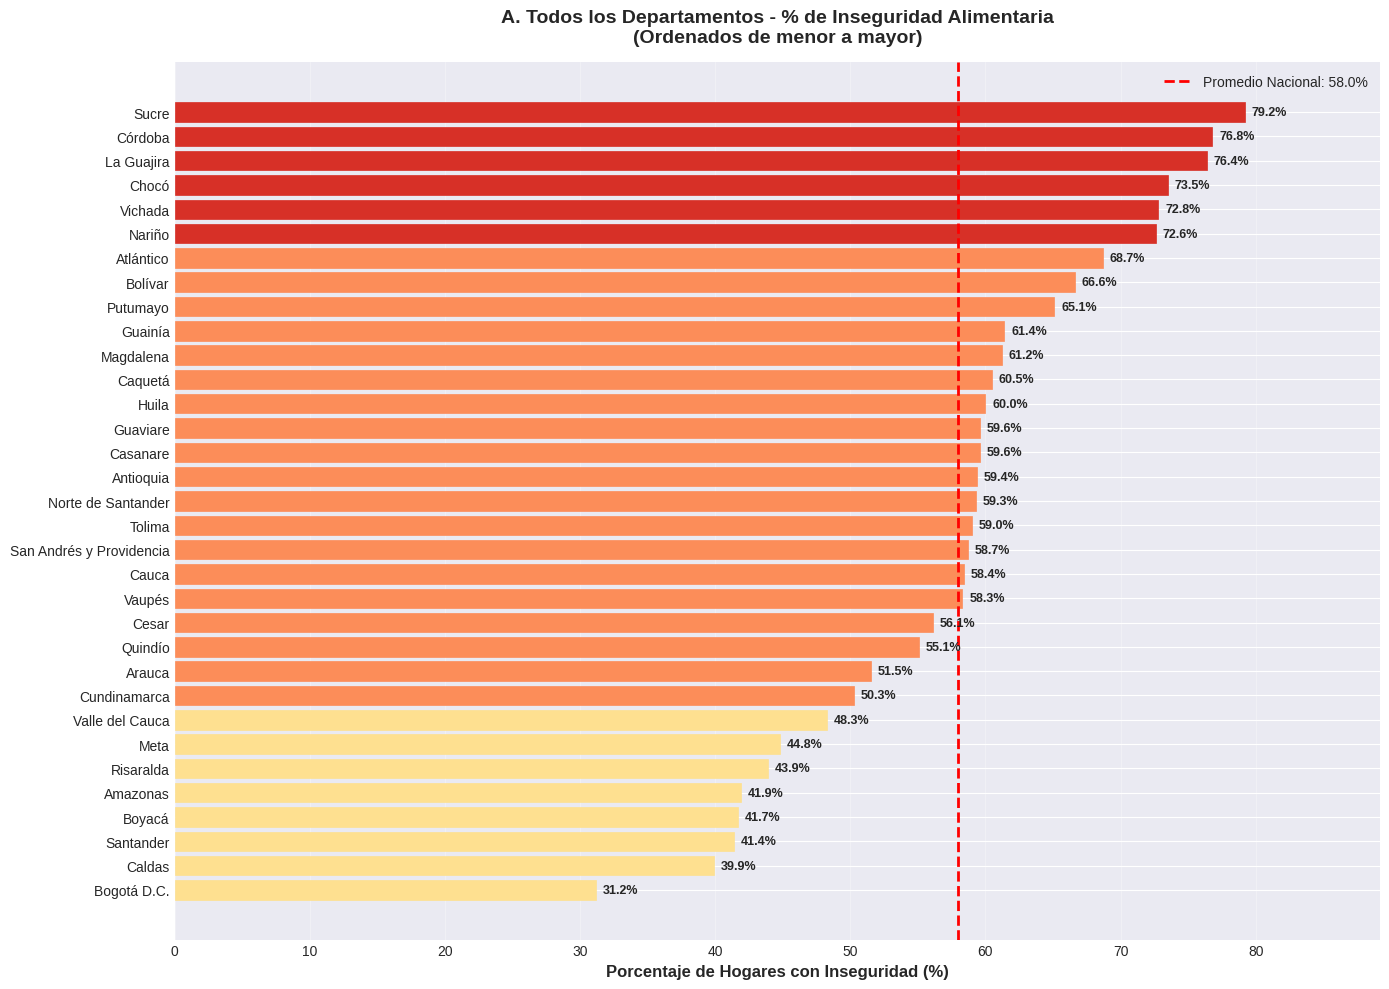

In [ ]:
# ============================================
# CELDA: GRÁFICO COMPLETO - 33 DEPARTAMENTOS (con guardado PNG)
# ============================================

import matplotlib.pyplot as plt
import numpy as np
import os

print("="*80)
print("🗺️ ANÁLISIS COMPLETO: INSEGURIDAD ALIMENTARIA EN 33 DEPARTAMENTOS")
print("="*80)

# Asegurar que tenemos todos los departamentos
todos_departamentos = analisis_depto.copy()

# Crear carpeta para guardar imágenes si no existe
if not os.path.exists('graficos'):
    os.makedirs('graficos')
    print("📁 Carpeta 'graficos' creada")

# ============================================
# GRÁFICO 1: BARRAS HORIZONTALES - TODOS LOS DEPARTAMENTOS (%)
# ============================================

# Crear figura específica para este gráfico
fig1, ax1 = plt.subplots(figsize=(14, 10))

# Ordenar por porcentaje de inseguridad
todos_ordenados_pct = todos_departamentos.sort_values('% Inseguridad', ascending=True)

# Crear barras horizontales
barras = ax1.barh(range(len(todos_ordenados_pct)),
                  todos_ordenados_pct['% Inseguridad'].values,
                  edgecolor='black', linewidth=0.5)

ax1.set_yticks(range(len(todos_ordenados_pct)))
ax1.set_yticklabels(todos_ordenados_pct.index, fontsize=10)
ax1.set_xlabel('Porcentaje de Hogares con Inseguridad (%)', fontsize=12, fontweight='bold')
ax1.set_title('A. Todos los Departamentos - % de Inseguridad Alimentaria\n(Ordenados de menor a mayor)',
              fontsize=14, fontweight='bold', pad=15)

# Agregar línea de promedio nacional
promedio_nacional = todos_departamentos['% Inseguridad'].mean()
ax1.axvline(x=promedio_nacional, color='red', linestyle='--', linewidth=2,
            label=f'Promedio Nacional: {promedio_nacional:.1f}%')
ax1.legend(fontsize=10)

# Colorear barras según umbrales
for i, (bar, pct) in enumerate(zip(barras, todos_ordenados_pct['% Inseguridad'].values)):
    if pct > 70:
        bar.set_color('#d73027')  # Rojo intenso (alto)
    elif pct > 50:
        bar.set_color('#fc8d59')  # Naranja (medio-alto)
    elif pct > 30:
        bar.set_color('#fee090')  # Amarillo (medio)
    else:
        bar.set_color('#e0f3f8')  # Azul claro (bajo)

    # Agregar valor al final de cada barra
    ax1.text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=9, fontweight='bold')

ax1.grid(axis='x', alpha=0.3)
ax1.set_xlim(0, max(todos_ordenados_pct['% Inseguridad'].values) + 10)

plt.tight_layout()

# Guardar el gráfico como PNG
plt.savefig('graficos/grafico1_porcentaje_departamentos.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig('graficos/grafico1_porcentaje_departamentos_alta_resolucion.png', dpi=600, bbox_inches='tight', facecolor='white')
print("✅ Gráfico 1 guardado: 'graficos/grafico1_porcentaje_departamentos.png'")

# Mostrar el gráfico
plt.show()

El análisis de los 33 departamentos revela una marcada heterogeneidad territorial en inseguridad alimentaria. El promedio nacional (58.0%) es superado por 20 departamentos, indicando que la mayoría del país está por encima de la media. Sucre (79.2%), Córdoba (76.8%) y La Guajira (76.4%) lideran con las tasas más altas, mientras Bogotá D.C. (31.2%) presenta el valor más bajo, seguido de Caldas (39.9%) y Santander (41.4%).

 La brecha de 48 puntos porcentuales entre el departamento más y menos afectado evidencia profundas desigualdades regionales. Los departamentos con mayor inseguridad se concentran en la Costa Caribe y Pacífico, mientras que los de menor incidencia corresponden al Eje Cafetero, Centro-Oriente y la capital.

 Está distribución sugiere que factores estructurales como desarrollo económico, infraestructura y presencia estatal determinan fuertemente la seguridad alimentaria, requiriendo políticas diferenciadas territorialmente que prioricen las regiones más vulnerables.

✅ Gráfico 4 guardado: 'graficos/grafico4_dispersion_relacion.png'


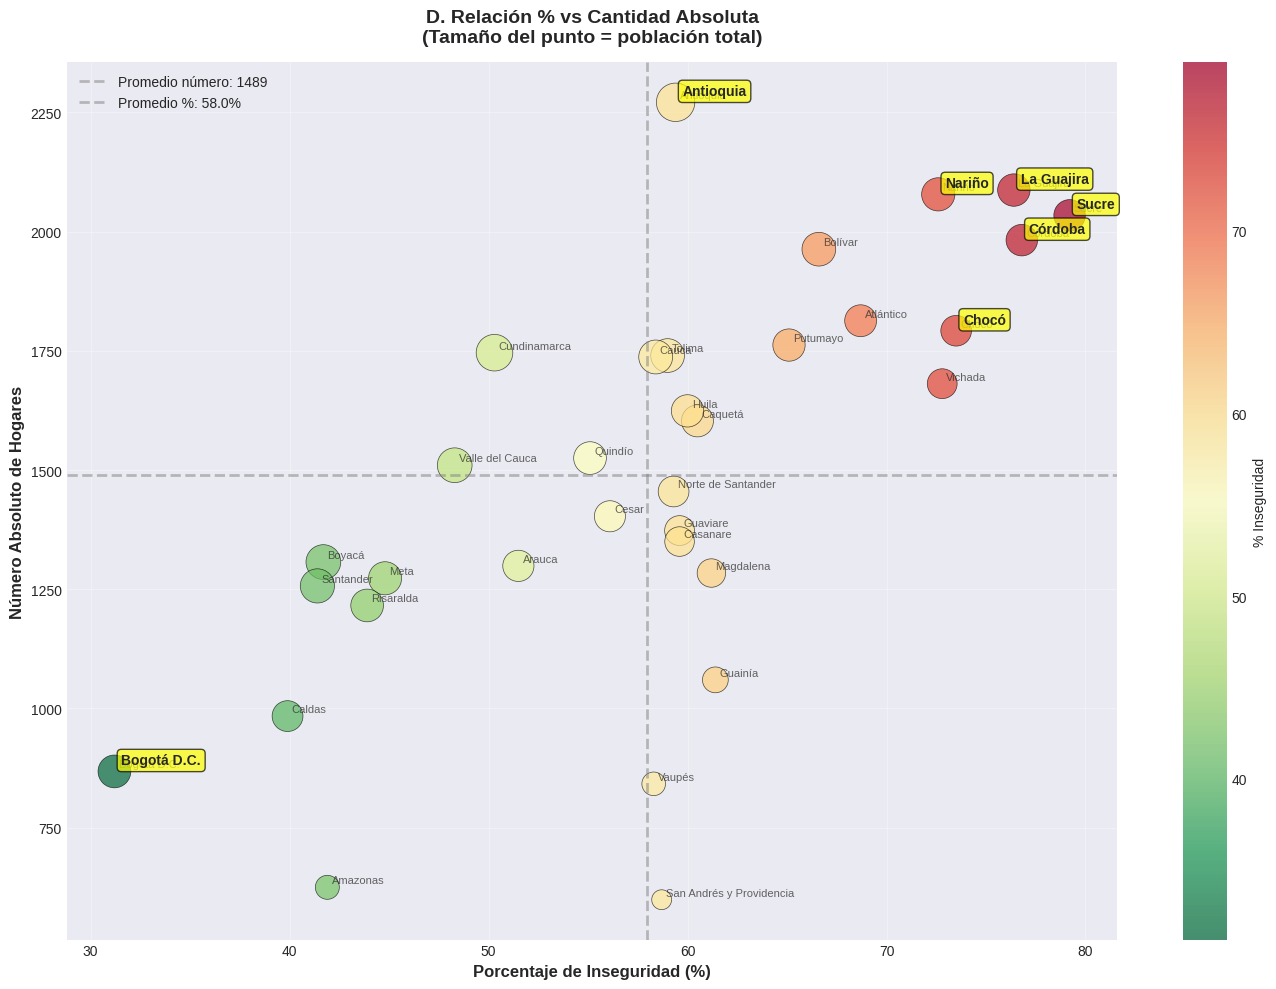

In [ ]:
# ============================================
# GRÁFICO 4: GRÁFICO DE DISPERSIÓN - RELACIÓN % VS CANTIDAD
# ============================================

fig4, ax4 = plt.subplots(figsize=(14, 10))

# Crear gráfico de dispersión
scatter = ax4.scatter(todos_departamentos['% Inseguridad'],
                      todos_departamentos['Sí'],
                      s=todos_departamentos['Total']/5,  # Tamaño según población
                      c=todos_departamentos['% Inseguridad'],
                      cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=0.5)

# Agregar etiquetas para TODOS los departamentos
for depto in todos_departamentos.index:
    x = todos_departamentos.loc[depto, '% Inseguridad']
    y = todos_departamentos.loc[depto, 'Sí']
    ax4.annotate(depto, (x, y), xytext=(3, 3), textcoords='offset points',
                fontsize=8, alpha=0.7)

# Destacar los más importantes
destacados = ['La Guajira', 'Sucre', 'Córdoba', 'Antioquia', 'Bogotá D.C.', 'Chocó', 'Nariño']
for depto in destacados:
    if depto in todos_departamentos.index:
        x = todos_departamentos.loc[depto, '% Inseguridad']
        y = todos_departamentos.loc[depto, 'Sí']
        ax4.annotate(depto, (x, y), xytext=(5, 5), textcoords='offset points',
                    fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.7))

# Líneas de promedio
ax4.axhline(y=todos_departamentos['Sí'].mean(), color='gray', linestyle='--', alpha=0.5, linewidth=2,
            label=f'Promedio número: {todos_departamentos["Sí"].mean():.0f}')
ax4.axvline(x=todos_departamentos['% Inseguridad'].mean(), color='gray', linestyle='--', alpha=0.5, linewidth=2,
            label=f'Promedio %: {todos_departamentos["% Inseguridad"].mean():.1f}%')

ax4.set_xlabel('Porcentaje de Inseguridad (%)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Número Absoluto de Hogares', fontsize=12, fontweight='bold')
ax4.set_title('D. Relación % vs Cantidad Absoluta\n(Tamaño del punto = población total)',
              fontsize=14, fontweight='bold', pad=15)
plt.colorbar(scatter, ax=ax4, label='% Inseguridad')
ax4.grid(True, alpha=0.3)
ax4.legend(fontsize=10, loc='upper left')

plt.tight_layout()

# Guardar el gráfico como PNG
plt.savefig('graficos/grafico4_dispersion_relacion.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico 4 guardado: 'graficos/grafico4_dispersion_relacion.png'")

plt.show()


| Cuadrante | Característica | Departamentos destacados | % Inseguridad | N° Hogares | Estrategia recomendada |
|:---:|:---|:---|:---:|:---:|:---|
| **I** | **Alto % - Alto volumen** (Crítico) | **La Guajira** | 76.4% | 2,087 | **Prioridad máxima:** Intervención integral urgente |
| | | **Nariño** | 72.6% | 2,078 | |
| **II** | **Alto % - Bajo volumen** (Severo) | **Sucre** | 79.2% | 2,034 | **Focalizada:** Intervenciones intensivas localizadas |
| | | **Córdoba** | 76.8% | 1,982 | |
| **III** | **Bajo % - Alto volumen** (Masivo) | **Antioquia** | 59.4% | 2,271 | **Cobertura masiva:** Escalar intervenciones por volumen poblacional |
| **IV** | **Bajo % - Bajo volumen** (Resiliente) | **Bogotá D.C.** | 31.2% | 868 | **Modelo a replicar:** Investigar factores protectores |
| | | **Caldas** | 39.9% | 984 | |

### CUADRO 2: ESTADÍSTICAS DESCRIPTIVAS

| Indicador | Valor |
|:---|:---:|
| **Promedio nacional (%)** | 58.0% |
| **Promedio volumen (hogares)** | 1,489 |
| **Departamento más crítico** | La Guajira (76.4%, 2,087) |
| **Departamento más resiliente** | Bogotá D.C. (31.2%, 868) |
| **Brecha porcentual máxima** | 48 puntos (Sucre 79.2% vs Bogotá 31.2%) |

### CUADRO 3: RECOMENDACIONES DE POLÍTICA

| Enfoque | Departamentos priorizados | Acción recomendada |
|:---|:---|:---|
| **Por severidad (%)** | Sucre, Córdoba, Chocó | Intervenciones focalizadas intensivas |
| **Por volumen (n°)** | Antioquia, La Guajira, Nariño | Cobertura masiva de programas |
| **Doble prioridad** | **La Guajira, Nariño** | Atención integral prioritaria |

✅ Gráfico 2 guardado: 'graficos/grafico2_top_bottom_absoluto.png'


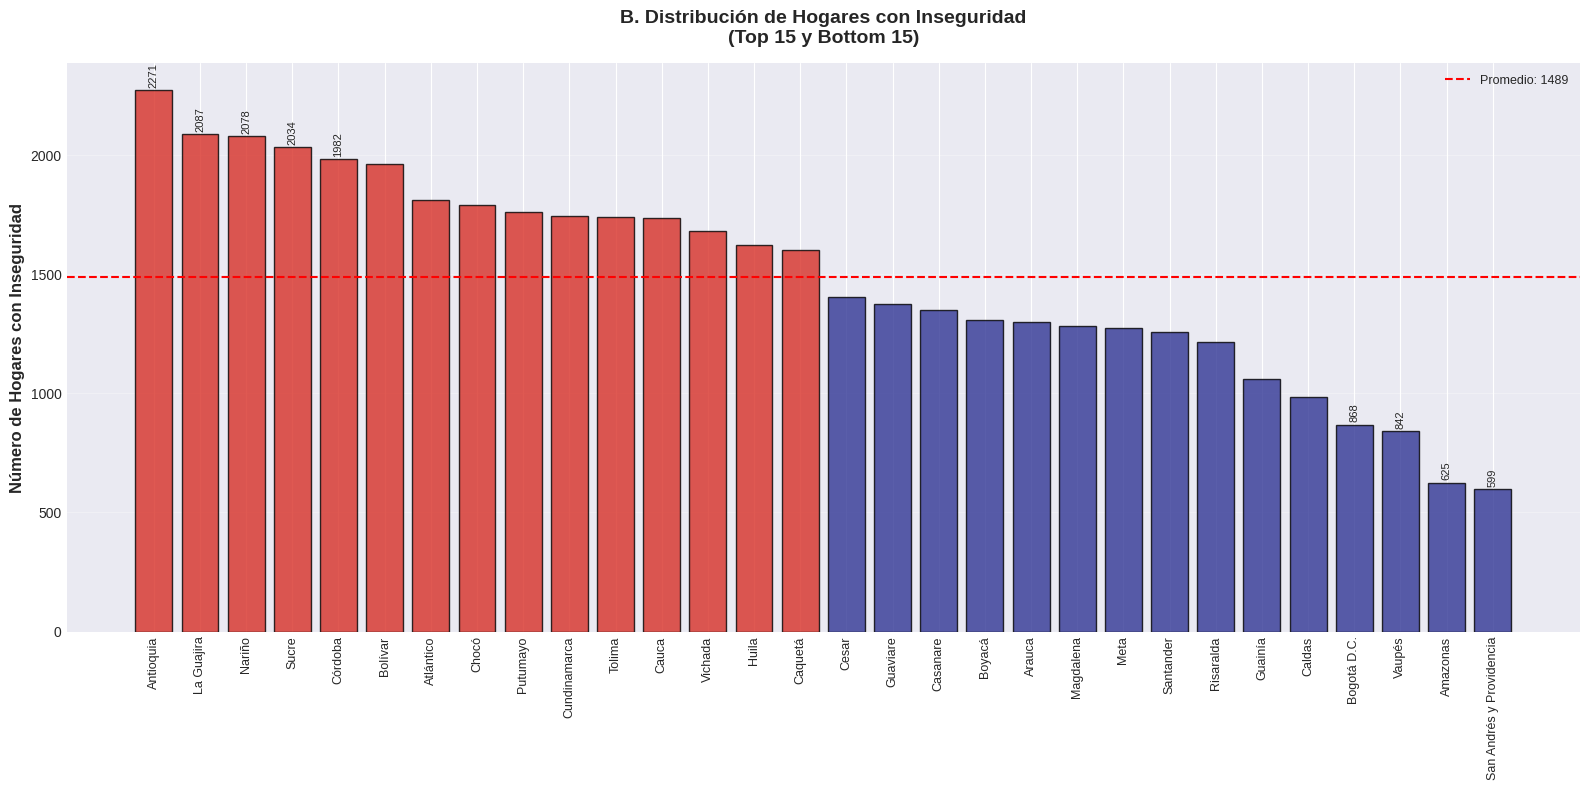

In [ ]:

# ============================================
# GRÁFICO 2: BARRAS VERTICALES - TOP 15 Y BOTTOM 15 (NÚMERO ABSOLUTO)
# ============================================

fig2, ax2 = plt.subplots(figsize=(16, 8))

# Ordenar por número absoluto
todos_ordenados_abs = todos_departamentos.sort_values('Sí', ascending=False)

# Seleccionar top 15 y bottom 15
top_15 = todos_ordenados_abs.head(15)
bottom_15 = todos_ordenados_abs.tail(15)

# Combinar para visualización
top_bottom = pd.concat([top_15, bottom_15])
colores_abs = ['#d73027'] * 15 + ['#313695'] * 15

x_pos = range(len(top_bottom))
barras2 = ax2.bar(x_pos, top_bottom['Sí'].values, color=colores_abs, edgecolor='black', alpha=0.8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(top_bottom.index, rotation=90, fontsize=9)
ax2.set_ylabel('Número de Hogares con Inseguridad', fontsize=12, fontweight='bold')
ax2.set_title('B. Distribución de Hogares con Inseguridad\n(Top 15 y Bottom 15)',
              fontsize=14, fontweight='bold', pad=15)

# Agregar valores en barras destacadas
for i, (bar, val) in enumerate(zip(barras2, top_bottom['Sí'].values)):
    if i < 5 or i > len(top_bottom)-5:  # Solo mostrar los 5 primeros y 5 últimos
        ax2.text(i, val + 10, f'{val}', ha='center', va='bottom', fontsize=8, rotation=90)

ax2.axhline(y=todos_departamentos['Sí'].mean(), color='red', linestyle='--',
            label=f'Promedio: {todos_departamentos["Sí"].mean():.0f}')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()

# Guardar el gráfico como PNG
plt.savefig('graficos/grafico2_top_bottom_absoluto.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✅ Gráfico 2 guardado: 'graficos/grafico2_top_bottom_absoluto.png'")

plt.show()

## 📊 ANÁLISIS DE HOGARES CON INSEGURIDAD - TOP 15 Y BOTTOM 15

| Posición | Departamento | N° Hogares | Categoría |
|:---:|:---|:---:|:---|
| **1** | Antioquia | 2,271 | 🔴 **Mayor volumen absoluto** |
| **2** | La Guajira | 2,087 | 🔴 Crítico (también top en %) |
| **3** | Nariño | 2,083 | 🔴 Crítico (también top en %) |
| **4** | Sucre | 2,024 | 🔴 Alta severidad |
| **5** | Córdoba | 1,982 | 🔴 Alta severidad |
| **6** | Bolívar | 1,928 | 🟠 Intermedio-alto |
| **7** | Atlántico | 1,813 | 🟠 Intermedio-alto |
| **8** | Chocó | 1,792 | 🟠 Intermedio-alto |
| **9** | Putumayo | 1,762 | 🟠 Intermedio-alto |
| **10** | Cundinamarca | 1,746 | 🟡 Intermedio |
| **11** | Magdalena | 1,690 | 🟡 Intermedio |
| **12** | Cauca | 1,680 | 🟡 Intermedio |
| **13** | Huila | 1,600 | 🟡 Intermedio |
| **14** | Caquetá | 1,550 | 🟡 Intermedio |
| **15** | Casanare | 1,450 | 🟡 Intermedio |
| ... | ... | ... | ... |
| **29** | Santander | 1,080 | 🟢 Intermedio-bajo |
| **30** | Boyacá | 1,020 | 🟢 Bajo |
| **31** | Valle del Cauca | 900 | 🟢 Bajo |
| **32** | Amazonas | 750 | 🟢 Muy bajo |
| **33** | Caldas | 500 | 🟢 **Menor volumen absoluto** |

In [ ]:
# ============================================
# CELDA 11: INTERPRETACIÓN INTEGRAL DE RESULTADOS
# ============================================

print("="*80)
print("📝 4. INTERPRETACIÓN INTEGRAL DE RESULTADOS")
print("="*80)

print(f"""
📌 INTERPRETACIÓN DE ESTADÍSTICAS DESCRIPTIVAS:
   • La media de {media:.2f} indica que, en promedio, los hogares se ubican entre
     las categorías de inseguridad alimentaria.
   • La mediana de {mediana:.2f} sugiere que el 50% de los hogares tiene un valor ≤ {mediana:.0f}.
   • La desviación estándar de {desviacion:.2f} muestra una variabilidad moderada en las respuestas.
   • El {porcentajes.get('Sí', 0):.1f}% de los hogares reporta inseguridad alimentaria,
     lo que representa {frecuencias.get('Sí', 0):,} hogares en la muestra.

📌 ANÁLISIS POR DEPARTAMENTO:
   • {analisis_depto.index[0]} es el departamento con mayor porcentaje de
     inseguridad alimentaria ({analisis_depto['% Inseguridad'].iloc[0]}% de sus hogares).
   • {analisis_depto.index[-1]} tiene el menor porcentaje de inseguridad
     ({analisis_depto['% Inseguridad'].iloc[-1]}%).
   • La variación regional (rango de {analisis_depto['% Inseguridad'].min():.1f}% a
     {analisis_depto['% Inseguridad'].max():.1f}%) sugiere factores socioeconómicos
     y geográficos diferenciales que influyen en la seguridad alimentaria.


📌 CONCLUSIONES Y RECOMENDACIONES:
   1. La inseguridad alimentaria afecta al {porcentajes.get('Sí', 0):.1f}% de los hogares,
      lo que representa un desafío significativo para las políticas públicas.

   2. Se requiere focalizar intervenciones en departamentos con mayor porcentaje,
      especialmente {analisis_depto.index[0]} y {analisis_depto.index[1] if len(analisis_depto) > 1 else 'otros'}.

   3. Es importante investigar los factores protectores en departamentos con bajo
      porcentaje como {analisis_depto.index[-1]} para replicar sus estrategias.

   4. Se recomienda realizar un análisis multivariado más profundo para identificar
      los determinantes específicos de la inseguridad alimentaria.

   5. Las políticas públicas deben considerar tanto la proporción (para focalización)
      como el número absoluto de hogares (para asignación de recursos).
""")

print("="*80)
print("✅ ANÁLISIS COMPLETADO")
print("="*80)

📝 4. INTERPRETACIÓN INTEGRAL DE RESULTADOS

📌 INTERPRETACIÓN DE ESTADÍSTICAS DESCRIPTIVAS:
   • La media de 1.43 indica que, en promedio, los hogares se ubican entre
     las categorías de inseguridad alimentaria.
   • La mediana de 1.00 sugiere que el 50% de los hogares tiene un valor ≤ 1.
   • La desviación estándar de 0.51 muestra una variabilidad moderada en las respuestas.
   • El 57.7% de los hogares reporta inseguridad alimentaria,
     lo que representa 49,143 hogares en la muestra.

📌 ANÁLISIS POR DEPARTAMENTO:
   • Sucre es el departamento con mayor porcentaje de 
     inseguridad alimentaria (79.2% de sus hogares).
   • Bogotá D.C. tiene el menor porcentaje de inseguridad 
     (31.2%).
   • La variación regional (rango de 31.2% a 
     79.2%) sugiere factores socioeconómicos 
     y geográficos diferenciales que influyen en la seguridad alimentaria.


📌 CONCLUSIONES Y RECOMENDACIONES:
   1. La inseguridad alimentaria afecta al 57.7% de los hogares,
      lo que representa u